In [1]:
!pip install numpy scipy matplotlib pandas scikit-learn pywavelets torch torchvision

  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pywavelets-1.10.0-cp314-cp314-win_amd64.whl.metadata (7.6 kB)
  Using cached torch-2.14.0-cp314-cp314-win_amd64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl.metadata (5.7 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
pip list

Package                 Version
----------------------- -----------
asttokens               3.0.2
cloudpickle             3.1.2
colorama                0.4.6
comm                    0.2.3
contourpy               1.4.0
cycler                  0.12.1
debugpy                 1.8.22
executing               2.2.1
filelock                4.0.3
fonttools               4.66.0
fsspec                  2026.9.0
ipykernel               7.3.0
ipython                 9.17.1
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
Jinja2                  3.1.6
joblib                  1.6.0
jupyter_client          8.10.0
jupyter_core            5.9.1
kiwisolver              1.5.1
MarkupSafe              3.0.3
matplotlib              3.11.2
matplotlib-inline       0.2.2
mpmath                  1.3.0
narwhals                2.26.0
nest-asyncio2           1.7.3
networkx                3.7
numpy                   2.5.3
packaging               26.3
pandas                  3.0.6
parso                   

In [11]:
import os

# 프로젝트의 로컬 data 폴더
DATA_PATH = os.path.join(os.getcwd(), "data")

# 데이터셋 확인
print(os.listdir(DATA_PATH))

['A', 'B', 'C', 'D', 'E']


In [ ]:
import numpy as np, glob, os

DATA_PATH = os.path.join(os.getcwd(), "data")

files = sorted(glob.glob(os.path.join(DATA_PATH, '**', '*.csv'), recursive=True))

print('파일 개수:', len(files))
print('예시 경로:', files[0])

x = np.loadtxt(files[0], delimiter=',', skiprows=1) # 형식에 맞게 변경

print('배열 모양:', x.shape) # 예: (3000, 2)
print('값 범위:', x.min(), '~', x.max())

# 피험자별 파일 수 세기
from collections import Counter

subs = [os.path.basename(os.path.dirname(f))
for f in files]
print(Counter(subs))

파일 개수: 250
예시 경로: c:\Workspace\sEMG-Based_Authentication_Project\data\A\a (1).csv
배열 모양: (3000, 2)
값 범위: -3.53656 ~ 4.33942
Counter({'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50})


A : a (15).csv


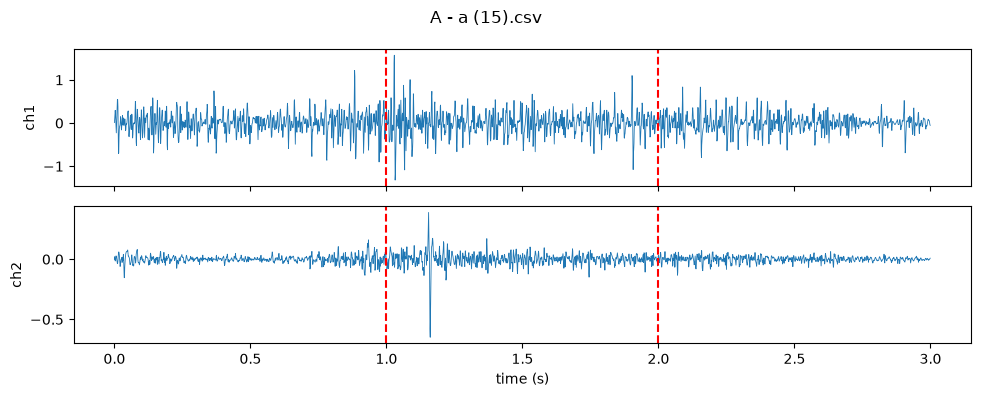

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random

def AllRead():
    for i, file in enumerate(files):
        # CSV 파일 읽기
        x = np.loadtxt(file, delimiter=',', skiprows=1)

        # (시간, 채널) 형태로 통일
        if x.shape[0] < x.shape[1]:
            x = x.T

        # 1000 Hz → 초 단위 시간축
        t = np.arange(len(x)) / 1000.0

        # 현재 파일 정보
        print(f'[{i + 1}/{len(files)}] {file}')
        print(f'Shape: {x.shape}')

        # 채널별 그래프
        fig, ax = plt.subplots(
            2, 1,
            figsize=(10, 4),
            sharex=True
        )

        for ch in range(2):
            ax[ch].plot(t, x[:, ch], lw=0.6)
            ax[ch].set_ylabel(f'ch{ch + 1}')

        # 1초, 2초 위치 표시
        for a in ax:
            a.axvline(1.0, color='r', ls='--')
            a.axvline(2.0, color='r', ls='--')

        ax[1].set_xlabel('time (s)')

        # 어떤 데이터인지 제목 표시
        fig.suptitle(os.path.basename(file))

        plt.tight_layout()
        plt.show()
        plt.close(fig)

def RandomSelectRead(select):
    select = select.upper()

    if select not in ['A', 'B', 'C', 'D', 'E']:
        print("A, B, C, D, E 중 하나를 입력해주세요.")
        return

    # 선택한 사람의 CSV만 가져오기
    select_files = [
        file for file in files
        if os.path.basename(os.path.dirname(file)) == select
    ]

    if not select_files:
        print(f"{select}의 CSV 파일이 없습니다.")
        return

    # 랜덤으로 하나 선택
    file = random.choice(select_files)

    # CSV 읽기
    x = np.loadtxt(file, delimiter=',', skiprows=1)

    if x.shape[0] < x.shape[1]:
        x = x.T

    # 시간축
    t = np.arange(len(x)) / 1000.0

    print(f'{select} : {os.path.basename(file)}')

    # 바로 그리기
    fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

    for ch in range(2):
        ax[ch].plot(t, x[:, ch], lw=0.6)
        ax[ch].set_ylabel(f'ch{ch + 1}')

    for a in ax:
        a.axvline(1.0, color='r', ls='--')
        a.axvline(2.0, color='r', ls='--')

    ax[1].set_xlabel('time (s)')
    fig.suptitle(f'{select} - {os.path.basename(file)}')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

RandomSelectRead('A')
#RandomSelectRead('C')
#RandomSelectRead('E')



In [14]:
from scipy.signal import butter, iirnotch, filtfilt
FS = 1000
#필터 적용 코드

def preprocess(x, fs=FS):
  # 1) 60 Hz 전원선 잡음 제거
  bn, an = iirnotch(60, 30, fs)
  x = filtfilt(bn, an, x, axis=0)
  # 2) 20~499 Hz 대역만 통과 (4차)
  b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
  return filtfilt(b, a, x, axis=0)

xf = preprocess(x)
print('전:', x.std(), ' 후:', xf.std())


전: 0.36156485032189156  후: 0.35825230094062965


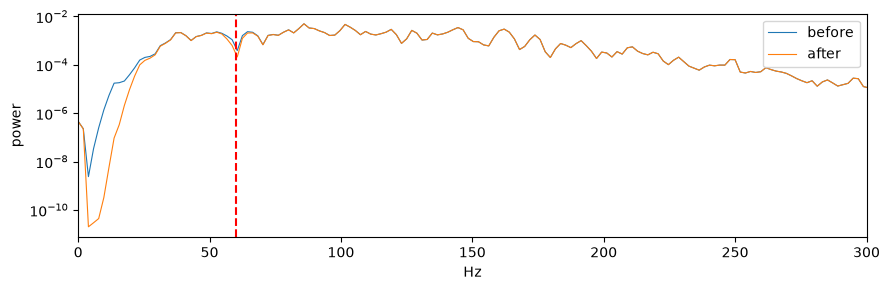

In [15]:
import matplotlib.pyplot as plt
from scipy.signal import welch

#필터 적용 확인

f0, P0 = welch(x[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf[:, 0], fs=FS, nperseg=512)
plt.figure(figsize=(9, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--')
plt.xlim(0, 300); plt.legend()
plt.xlabel('Hz'); plt.ylabel('power')
plt.tight_layout(); plt.savefig('filter_check.png', dpi=120)


In [16]:
WIN, HOP = 300, 150 # 샘플 단위 (1000Hz -> 300ms, 150ms)

# 슬라이딩 윈도우로 자르기

def make_windows(x, win=WIN, hop=HOP):
  """x: (시간, 채널) -> (윈도우수, win, 채널)"""
  n = (len(x) - win) // hop + 1
  return np.stack([x[i*hop : i*hop+win] for i in range(n)])

w = make_windows(xf)
print('윈도우 배열 모양:', w.shape) # (19, 300, 2)


윈도우 배열 모양: (19, 300, 2)


In [17]:
# min-max 정규화

def minmax(w, eps=1e-8): #"""w: (윈도우수, 시간, 채널)"""
  mn = w.min(axis=(1, 2), keepdims=True)
  mx = w.max(axis=(1, 2), keepdims=True)
  return (w - mn) / (mx - mn + eps)

wn = minmax(w)
print('값 범위:', wn.min(), '~', wn.max())


값 범위: 0.0 ~ 0.9999999987119951


입력 텐서 모양: (3, 32, 300)


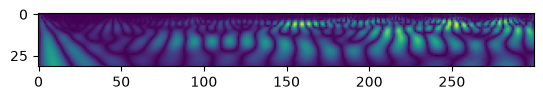

In [18]:
import pywt

SCALES = np.arange(1, 33) # 스케일 32개

def to_cwt(one_window, wavelet='morl'): #"""(300, 2) -> (3, 32, 300)"""
  maps = []
  for ch in range(one_window.shape[1]):
    coef, _ = pywt.cwt(one_window[:, ch], SCALES, wavelet)
    maps.append(np.abs(coef)) # (32, 300)

  maps.append((maps[0] + maps[1]) / 2) # 3번째 채널
  return np.stack(maps).astype(np.float32)

t = to_cwt(wn[0])
print('입력 텐서 모양:', t.shape) # (3, 32, 300)
plt.imshow(t[0])

In [19]:
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split

DATA_PATH = os.path.join(os.getcwd(), "data")

# =========================================================
# 0. 파일 목록
# =========================================================

files = sorted(
    glob.glob(
        os.path.join(DATA_PATH, '**', '*.csv'),
        recursive=True
    )
)

print("전체 파일 수:", len(files))


# =========================================================
# 1. 클래스 정의
# A ~ E = 피험자 5명
# =========================================================

CLASS_NAMES = ['A', 'B', 'C', 'D', 'E']

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

print(CLASS_TO_IDX)
# {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}


# =========================================================
# 2. CSV 불러오기
# =========================================================

def load(f):
    """
    csv 파일 -> (시간, 채널)
    예: (3000, 2)
    """

    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    return x


# =========================================================
# 3. 파일에서 라벨 얻기
# =========================================================

def label_of(f):
    """
    .../data/A/a (1).csv -> 0
    .../data/B/b (1).csv -> 1
    ...
    """

    subject = os.path.basename(
        os.path.dirname(f)
    )

    return CLASS_TO_IDX[subject]


# =========================================================
# 4. 파일별 라벨
# =========================================================

labels = np.array(
    [label_of(f) for f in files],
    dtype=np.int64
)

print("라벨 종류:", np.unique(labels))
print("라벨 개수:", np.bincount(labels))

전체 파일 수: 250
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
라벨 종류: [0 1 2 3 4]
라벨 개수: [50 50 50 50 50]


In [20]:
from sklearn.model_selection import train_test_split

# 1) 시행 단위로 먼저 분할 ← 순서가 핵심
tr_files, te_files = train_test_split(
  files,
  test_size=0.2,
  stratify=labels,
  random_state=42
  )

# 2) 각 집합 안에서만 윈도우 생성
def build(flist):
  X, y = [], []

  for f in flist:
    sig = preprocess(load(f))
    for w in minmax(make_windows(sig)):
      X.append(to_cwt(w)); y.append(label_of(f))

  return np.stack(X), np.array(y)

Xtr, ytr = build(tr_files)
Xte, yte = build(te_files)


In [21]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# NumPy -> PyTorch Tensor
Xtr_tensor = torch.from_numpy(Xtr).float()
ytr_tensor = torch.from_numpy(ytr).long()

print("Xtr:", Xtr_tensor.shape)
print("ytr:", ytr_tensor.shape)

# Dataset 생성
train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("배치 개수:", len(train_loader))

Xtr: torch.Size([3800, 3, 32, 300])
ytr: torch.Size([3800])
배치 개수: 238


In [22]:
import numpy as np
import pandas as pd

# 제출물 표

print("Train X:", Xtr.shape)
print("Train y:", ytr.shape)
print("Test X :", Xte.shape)
print("Test y :", yte.shape)

classes = np.unique(np.concatenate([ytr, yte]))

summary = pd.DataFrame({
    "Class": classes,
    "Train": [(ytr == c).sum() for c in classes],
    "Test": [(yte == c).sum() for c in classes]
})

summary.loc["Total"] = [
    "Total",
    len(ytr),
    len(yte)
]

display(summary)

Train X: (3800, 3, 32, 300)
Train y: (3800,)
Test X : (950, 3, 32, 300)
Test y : (950,)


,Class,Train,Test
0,0,760,190
1,1,760,190
2,2,760,190
3,3,760,190
4,4,760,190
Total,Total,3800,950


In [ ]:
# ============================================================
# DenseNet161 + Dropout
#
# [재현성 설정]
# Random Seed        : 42
# Python random      : 42
# NumPy Seed         : 42
# PyTorch Seed       : 42
# CUDA Seed          : 42
# DataLoader Shuffle : Seed 42
#
# 추가 설정
# - cuDNN deterministic = True
# - cuDNN benchmark = False
# - TF32 = False
# - deterministic algorithms 사용
#
# 학습 설정
# - Model      : DenseNet161
# - Pretrained : 사용하지 않음
# - Dropout    : 0.5
# - Optimizer  : Adam
# - LR         : 0.001
# - Batch Size : 16
# - Epoch      : 45
# - Loss       : CrossEntropyLoss
# ============================================================

import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. 재현성 설정
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


def set_seed(seed=SEED):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

    torch.use_deterministic_algorithms(True)


set_seed()


# ============================================================
# 2. Device
# ============================================================

dev = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", dev)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("PyTorch:", torch.__version__)
print("Seed   :", SEED)


# ============================================================
# 3. Dataset
# ============================================================

train_dataset = TensorDataset(
    torch.tensor(Xtr, dtype=torch.float32),
    torch.tensor(ytr, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(Xte, dtype=torch.float32),
    torch.tensor(yte, dtype=torch.long)
)


generator = torch.Generator()
generator.manual_seed(SEED)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    generator=generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)


print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


# ============================================================
# 4. DenseNet161 + Dropout
# ============================================================

set_seed()

model = densenet161(
    weights=None
)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(2208, 5)
)

model = model.to(dev)


# ============================================================
# 5. Optimizer / Loss
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()


# ============================================================
# 6. 학습
# ============================================================

EPOCHS = 45

best_acc = 0.0
best_epoch = 0
best_state = None

history = []


for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0


    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        optimizer.zero_grad()

        output = model(xb)

        loss = criterion(
            output,
            yb
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = output.argmax(dim=1)

        train_correct += (
            pred == yb
        ).sum().item()

        train_total += yb.size(0)


    avg_train_loss = (
        train_loss /
        len(train_loader)
    )

    train_acc = (
        train_correct /
        train_total *
        100
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0


    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(dev)
            yb = yb.to(dev)

            output = model(xb)

            loss = criterion(
                output,
                yb
            )

            test_loss += loss.item()

            pred = output.argmax(dim=1)

            test_correct += (
                pred == yb
            ).sum().item()

            test_total += yb.size(0)


    avg_test_loss = (
        test_loss /
        len(test_loader)
    )

    test_acc = (
        test_correct /
        test_total *
        100
    )


    # --------------------------------------------------------
    # 기록
    # --------------------------------------------------------

    history.append({
        "Epoch": epoch + 1,
        "Train Loss": avg_train_loss,
        "Train Accuracy": train_acc,
        "Test Loss": avg_test_loss,
        "Test Accuracy": test_acc
    })


    # --------------------------------------------------------
    # Best Model
    # --------------------------------------------------------

    if test_acc > best_acc:

        best_acc = test_acc
        best_epoch = epoch + 1

        best_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # 출력
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Accuracy: {train_acc:6.2f}% | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Accuracy: {test_acc:6.2f}%"
    )


# ============================================================
# 7. Best Model 복구
# ============================================================

model.load_state_dict(
    best_state
)

print()
print("========================================")
print("DenseNet161 + Dropout 학습 완료")
print("========================================")

print(
    f"Best Epoch    : {best_epoch}"
)

print(
    f"Best Accuracy : {best_acc:.2f}%"
)


# ============================================================
# 8. 최종 평가
# ============================================================

model.eval()

y_true = []
y_pred = []


with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(dev)

        output = model(xb)

        pred = output.argmax(dim=1)

        y_true.extend(
            yb.numpy()
        )

        y_pred.extend(
            pred.cpu().numpy()
        )


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 9. 과제용 성능 표
# ============================================================

result = pd.DataFrame([{
    "Model": "DenseNet161 + Dropout",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}])


display(
    result.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-score": "{:.2%}"
    })
)


# ============================================================
# 10. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "A",
        "B",
        "C",
        "D",
        "E"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "DenseNet161 + Dropout Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ResNet18 + Dropout
#
# [재현성 설정]
# Random Seed        : 42
# Python random      : 42
# NumPy Seed         : 42
# PyTorch Seed       : 42
# CUDA Seed          : 42
# DataLoader Shuffle : Seed 42
#
# 추가 설정
# - cuDNN deterministic = True
# - cuDNN benchmark = False
# - TF32 = False
# - deterministic algorithms 사용
#
# 학습 설정
# - Model      : ResNet18
# - Pretrained : 사용하지 않음
# - Dropout    : 0.5
# - Optimizer  : Adam
# - LR         : 0.001
# - Batch Size : 16
# - Epoch      : 45
# - Loss       : CrossEntropyLoss
# ============================================================

import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. 재현성 설정
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


def set_seed(seed=SEED):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

    torch.use_deterministic_algorithms(True)


set_seed()


# ============================================================
# 2. Device
# ============================================================

dev = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", dev)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("PyTorch:", torch.__version__)
print("Seed   :", SEED)


# ============================================================
# 3. Dataset
# ============================================================

train_dataset = TensorDataset(
    torch.tensor(Xtr, dtype=torch.float32),
    torch.tensor(ytr, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(Xte, dtype=torch.float32),
    torch.tensor(yte, dtype=torch.long)
)


generator = torch.Generator()
generator.manual_seed(SEED)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    generator=generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)


print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


# ============================================================
# 4. ResNet18 + Dropout
# ============================================================

set_seed()

model = resnet18(
    weights=None
)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, 5)
)

model = model.to(dev)


# ============================================================
# 5. Optimizer / Loss
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()


# ============================================================
# 6. 학습
# ============================================================

EPOCHS = 45

best_acc = 0.0
best_epoch = 0
best_state = None

history = []


for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0


    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        optimizer.zero_grad()

        output = model(xb)

        loss = criterion(
            output,
            yb
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = output.argmax(dim=1)

        train_correct += (
            pred == yb
        ).sum().item()

        train_total += yb.size(0)


    avg_train_loss = (
        train_loss /
        len(train_loader)
    )

    train_acc = (
        train_correct /
        train_total *
        100
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0


    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(dev)
            yb = yb.to(dev)

            output = model(xb)

            loss = criterion(
                output,
                yb
            )

            test_loss += loss.item()

            pred = output.argmax(dim=1)

            test_correct += (
                pred == yb
            ).sum().item()

            test_total += yb.size(0)


    avg_test_loss = (
        test_loss /
        len(test_loader)
    )

    test_acc = (
        test_correct /
        test_total *
        100
    )


    # --------------------------------------------------------
    # 기록
    # --------------------------------------------------------

    history.append({
        "Epoch": epoch + 1,
        "Train Loss": avg_train_loss,
        "Train Accuracy": train_acc,
        "Test Loss": avg_test_loss,
        "Test Accuracy": test_acc
    })


    # --------------------------------------------------------
    # Best Model
    # --------------------------------------------------------

    if test_acc > best_acc:

        best_acc = test_acc
        best_epoch = epoch + 1

        best_state = copy.deepcopy(
            model.state_dict()
        )


    # --------------------------------------------------------
    # 출력
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Accuracy: {train_acc:6.2f}% | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Accuracy: {test_acc:6.2f}%"
    )


# ============================================================
# 7. Best Model 복구
# ============================================================

model.load_state_dict(
    best_state
)

print()
print("========================================")
print("ResNet18 + Dropout 학습 완료")
print("========================================")

print(
    f"Best Epoch    : {best_epoch}"
)

print(
    f"Best Accuracy : {best_acc:.2f}%"
)


# ============================================================
# 8. 최종 평가
# ============================================================

model.eval()

y_true = []
y_pred = []


with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(dev)

        output = model(xb)

        pred = output.argmax(dim=1)

        y_true.extend(
            yb.numpy()
        )

        y_pred.extend(
            pred.cpu().numpy()
        )


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 9. 과제용 성능 표
# ============================================================

result = pd.DataFrame([{
    "Model": "ResNet18 + Dropout",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}])


display(
    result.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-score": "{:.2%}"
    })
)


# ============================================================
# 10. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "A",
        "B",
        "C",
        "D",
        "E"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "ResNet18 + Dropout Confusion Matrix"
)

plt.tight_layout()
plt.show()

Device : cpu
PyTorch: 2.14.0+cpu
Seed   : 42


NameError: name 'Xtr' is not defined